# Phase 0.5 — Does the wrist camera help? (second-camera test)

Tests the Phase 0.5 hypotheses in **[08 §A.4](08_data_quality_research.md)** on the toolkit-cylinder dataset.
Adapted from `measure_data_quality.ipynb` (07).

**Dataset:** `HALDijkstraaa/so101_toolkit_cylinder_20260917_165544` — 50 clean episodes, cameras `top` + `wrist`.

**The one idea behind everything here — action divergence.**
A policy sees an observation and must output an action. Take a frame, find the *k* frames **from other
episodes** that look most similar to it. If those look-alike frames were followed by *different* motions,
the observation doesn't contain enough information to pick the action → the policy has to average or guess.
We measure that spread (0 = look-alikes always did the same thing, 1 = as random as the whole dataset) and
compare it across observation spaces: **top only, wrist only, top + wrist**, controls, and joint state.

| Hypothesis (08) | Prediction | Where to look |
|---|---|---|
| **H-a** wrist beats top in fine phases | wrist < top in *grasp* and *insert* | Section 5 |
| **H-b** top beats wrist in coarse phases | top < wrist in *reach* | Section 5 |
| **H-c** views complement (**pass test**) | top+wrist < top by more than the shuffled control, every k | Section 4 |
| **H-d** aliasing in fine phases | close in top, far in wrist, different actions; peaks in grasp/insert | Section 6 |
| **H-e** joint state ambiguous at start | state divergence highest in *reach*, where top is low | Section 5 |
| **H-f** wrist frames more varied | wrist diversity > top (descriptive only) | Section 7 |

**Sections:** 0 Setup · 1 Load, trim idle frames, find phases, sample · 2 Embed (cached) · 3 Divergence ·
4 Pass test (H-c) · 5 By phase (H-a/b/e) · 6 Aliasing (H-d) · 7 Diversity (H-f) · 8 How to read the results

> **Kernel:** `Python (lerobot 0.6.1)`. First full run: ~5 min (downloads DINOv2 ~90 MB, decodes ~8k images).
> Later runs reuse `phase05_cache.npz`.

## Section 0 — Setup

In [1]:
import os, glob, json, hashlib, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")
%matplotlib inline
import matplotlib.pyplot as plt

# ---- CONFIG (edit these) ---------------------------------------------------
REPO_ID      = "HALDijkstraaa/so101_toolkit_cylinder_20260917_165544"
DATASET_ROOT = os.path.expanduser(f"~/.cache/huggingface/lerobot/{REPO_ID}")   # local copy from recording
CACHE        = os.path.join(os.getcwd(), "phase05_cache.npz")                   # Section 2 writes it

# ---- Network ---------------------------------------------------------------
# This laptop routes traffic through a local proxy (verge-mihomo on 127.0.0.1:7897). A kernel started
# from the VS Code app does NOT inherit the shell's proxy variables, so Hugging Face downloads hang
# ("'timed out' thrown while requesting HEAD ..."). Set them here, before transformers is imported.
PROXY = "http://127.0.0.1:7897"          # set to None when the proxy is off
if PROXY:
    os.environ["HTTP_PROXY"] = os.environ["HTTPS_PROXY"] = PROXY
    os.environ["NO_PROXY"] = "localhost,127.0.0.1,::1"      # keep local traffic off the proxy
# DINOv2 is already in ~/.cache/huggingface/hub, so the network isn't needed at all. Uncomment to skip
# every Hub request (comment it out again if you switch DINO_MODEL):
# os.environ["HF_HUB_OFFLINE"] = "1"

CAMS  = ["top", "wrist"]                   # camera names used at record time
DINO_MODEL = "facebook/dinov2-small"       # 384-d, same as 07 (try "facebook/dinov2-base" for 768-d)

# Idle-frame trimming (Section 1b). Joint units are LeRobot's normalized range (-100..100; gripper 0..100).
TRIM_THRESH = 2.0     # an episode "starts" when any joint has moved > 2 units from the first frame,
                      # and "ends" at the last frame that is still > 2 units away from the final pose
TRIM_PAD    = 5       # keep 5 extra frames on each side so the very first/last motion is not cut

# Phase detection from the gripper (Section 1c)
GRIP_OPEN   = 15.0    # gripper above this = opened for approach
GRIP_HOLD   = 14.0    # after opening, dropping below this = closed on the cylinder (grasp)
RELEASE_GAP = 3.0     # during the hold, rising > 3 units above the hold level = release
FINE_WIN    = 30      # frames (1 s) BEFORE the grasp/release moment belong to the "grasp"/"insert" phase
POST_WIN    = 15      # frames (0.5 s) AFTER it, so the whole closing/opening edge of the gripper is inside
                      # the phase: the detected moment is mid-edge, and the fingers keep moving after it

FRAMES_PER_EPISODE = 80        # uniform sample inside the trimmed range
HORIZON  = 10                  # "next motion" = commanded pose 10 frames (1/3 s) ahead minus current pose
K_LIST   = [5, 10, 20]         # neighbors for divergence
K_MAIN   = 10                  # k used for the per-phase and aliasing plots
N_SHUFFLE = 5                  # shuffled-wrist control repeats
N_BOOT    = 2000               # episode bootstrap resamples

# Quick end-to-end check on a few episodes (writes a separate cache). Leave off for the real run.
SMOKE = os.environ.get("PHASE05_SMOKE") == "1"
if SMOKE:
    FRAMES_PER_EPISODE, N_BOOT = 12, 200
    CACHE = CACHE.replace(".npz", "_smoke.npz")

PHASES = ["reach", "grasp", "transport", "insert", "retreat"]
DEVICE = "cuda" if __import__("torch").cuda.is_available() else "cpu"
print("device:", DEVICE, "| dataset:", DATASET_ROOT, "| exists:", os.path.isdir(DATASET_ROOT))

device: cuda | dataset: /home/bj/.cache/huggingface/lerobot/HALDijkstraaa/so101_toolkit_cylinder_20260917_165544 | exists: True


## Section 1 — Load, trim idle frames, find phases, sample

Only the parquet tables (joint state + action, no images) are needed here, so this section is fast.

- **1a** load every frame's `observation.state` (follower joints) and `action` (leader joints = the command).
- **1b** **trim idle frames**: at the start you sit still before moving, at the end the arm is parked.
  Those frames look identical across episodes and have zero motion, so they would inflate "consistency".
- **1c** **find phases** from the gripper signal: *open → close on cylinder → open to release*.
- **1d** plot a few episodes to check trimming and phases **by eye** before trusting anything downstream.
- **1e** sample frames evenly inside the trimmed range and compute the action targets.

In [2]:
# ---- 1a. Per-frame table
data_files = sorted(glob.glob(os.path.join(DATASET_ROOT, "data", "chunk-*", "file-*.parquet")))
tbl = pd.concat([pd.read_parquet(f, columns=["episode_index", "frame_index", "index", "action", "observation.state"])
                 for f in data_files], ignore_index=True).sort_values("index").reset_index(drop=True)
EPISODES = sorted(tbl.episode_index.unique())
if SMOKE: EPISODES = EPISODES[:6]
JOINTS = ["shoulder_pan", "shoulder_lift", "elbow_flex", "wrist_flex", "wrist_roll", "gripper"]

# Per episode: arrays of state (T,6), action (T,6) and the global dataset index of each frame
EP = {}
for ep in EPISODES:
    g = tbl[tbl.episode_index == ep]
    EP[ep] = dict(state=np.stack(g["observation.state"]).astype(np.float32),
                  action=np.stack(g["action"]).astype(np.float32),
                  gidx=g["index"].to_numpy())
print(f"{len(EPISODES)} episodes, {sum(len(v['state']) for v in EP.values())} frames")

50 episodes, 37690 frames


In [3]:
# ---- 1b. Trim idle frames
# Intuition: measure how far the arm is from where it STARTED (for the start cut) and from where it
# ENDED (for the end cut). Using the max over joints means "any joint moved". A distance-from-pose test is
# more robust than a per-frame speed test, because slow deliberate motion has tiny per-frame speed.
def trim_range(state, thresh=TRIM_THRESH, pad=TRIM_PAD):
    dev_start = np.abs(state - state[0]).max(axis=1)     # (T,) how far from the first pose
    dev_end   = np.abs(state - state[-1]).max(axis=1)    # (T,) how far from the final pose
    moved = np.flatnonzero(dev_start > thresh)
    unsettled = np.flatnonzero(dev_end > thresh)
    if len(moved) == 0 or len(unsettled) == 0:           # never moved: keep everything
        return 0, len(state) - 1
    s = max(0, moved[0] - pad)
    e = min(len(state) - 1, unsettled[-1] + pad)
    return s, e

for ep in EPISODES:
    EP[ep]["t0"], EP[ep]["t1"] = trim_range(EP[ep]["state"])

trim = pd.DataFrame([dict(ep=ep, frames=len(EP[ep]["state"]), start=EP[ep]["t0"], end=EP[ep]["t1"],
                          kept=EP[ep]["t1"] - EP[ep]["t0"] + 1) for ep in EPISODES])
trim["cut_start_s"] = trim.start / 30; trim["cut_end_s"] = (trim.frames - 1 - trim.end) / 30
print("seconds cut at start / end (median):", trim.cut_start_s.median().round(2), "/", trim.cut_end_s.median().round(2))
display(trim.describe().round(1))

seconds cut at start / end (median): 2.3 / 1.42


,ep,frames,start,end,kept,cut_start_s,cut_end_s
count,50.0,50.0,50.0,50.0,50.0,50.0,50.0
mean,24.5,753.8,69.4,707.3,638.9,2.3,1.5
std,14.6,63.7,23.8,63.0,55.9,0.8,0.7
min,0.0,628.0,29.0,596.0,538.0,1.0,0.7
25%,12.2,708.0,50.2,657.2,601.8,1.7,1.0
50%,24.5,748.0,69.0,702.0,635.0,2.3,1.4
75%,36.8,797.8,79.0,753.8,677.0,2.6,1.7
max,49.0,880.0,136.0,850.0,773.0,4.5,3.8


In [4]:
# ---- 1c. Phases from the gripper
# The gripper trace in every episode looks like:  closed(~1) -> OPEN(~27-31) -> HOLD on cylinder(~9-11)
#                                                 -> OPEN to release(~15-23) -> closed at home(~1)
# grasp   = first frame after opening where the gripper closes below GRIP_HOLD
# release = first frame (after the hold settles) where it rises RELEASE_GAP above the hold level
# Phases (frame ranges inside the trimmed episode):
#   reach     [t0,                grasp - FINE_WIN)     move from home toward the cylinder
#   grasp     [grasp - FINE_WIN,   grasp + POST_WIN)     1 s before + 0.5 s after the fingers close
#   transport [grasp + POST_WIN,   release - FINE_WIN)   carry the cylinder to the fixture
#   insert    [release - FINE_WIN, release + POST_WIN)   1 s before + 0.5 s after letting go
#   retreat   [release + POST_WIN, t1]                   back to home
# The POST_WIN tail matters: grasp/release are detected part-way down/up the gripper edge, so without it
# the rest of the closing (or opening) motion would be counted as transport (or retreat).
def find_phases(state, t0, t1):
    grip = state[:, 5]
    opened = np.flatnonzero(grip[t0:t1 + 1] > GRIP_OPEN)
    if len(opened) == 0: return None
    t_open = t0 + opened[0]
    closed = np.flatnonzero(grip[t_open:t1 + 1] < GRIP_HOLD)
    if len(closed) == 0: return None
    t_grasp = t_open + closed[0]
    hold = np.median(grip[t_grasp + 5: t_grasp + 20])            # settled hold level on the cylinder
    rel = np.flatnonzero(grip[t_grasp + 10: t1 + 1] > hold + RELEASE_GAP)
    if len(rel) == 0: return None
    t_release = t_grasp + 10 + rel[0]
    return t_open, t_grasp, t_release

def phase_labels(T, t0, t1, ev):
    lab = np.full(T, -1)                                          # -1 = trimmed away / unknown
    if ev is None: return lab
    _, g, r = ev
    bounds = [t0, g - FINE_WIN, g + POST_WIN, r - FINE_WIN, r + POST_WIN, t1 + 1]
    bounds = np.clip(bounds, t0, t1 + 1)
    bounds = np.maximum.accumulate(bounds)        # keep the cuts ordered even if a phase is very short
    for p in range(5):
        lab[bounds[p]:bounds[p + 1]] = p
    return lab

bad = []
for ep in EPISODES:
    d = EP[ep]
    ev = find_phases(d["state"], d["t0"], d["t1"])
    d["events"] = ev
    d["phase"] = phase_labels(len(d["state"]), d["t0"], d["t1"], ev)
    if ev is None: bad.append(ep)
print("phase detection failed for episodes:", bad or "none")
dur = pd.DataFrame([{PHASES[p]: (EP[ep]["phase"] == p).sum() / 30 for p in range(5)} for ep in EPISODES if EP[ep]["events"]])
print("phase durations (s):"); display(dur.describe().round(2))

phase detection failed for episodes: none
phase durations (s):


,reach,grasp,transport,insert,retreat
count,50.00,50.0,50.00,50.0,50.00
mean,7.64,1.5,5.85,1.5,4.80
std,0.98,0.0,1.35,0.0,0.70
min,5.00,1.5,3.90,1.5,3.43
25%,7.01,1.5,4.94,1.5,4.24
50%,7.62,1.5,5.62,1.5,4.72
75%,8.35,1.5,6.42,1.5,5.38
max,9.77,1.5,10.57,1.5,6.33


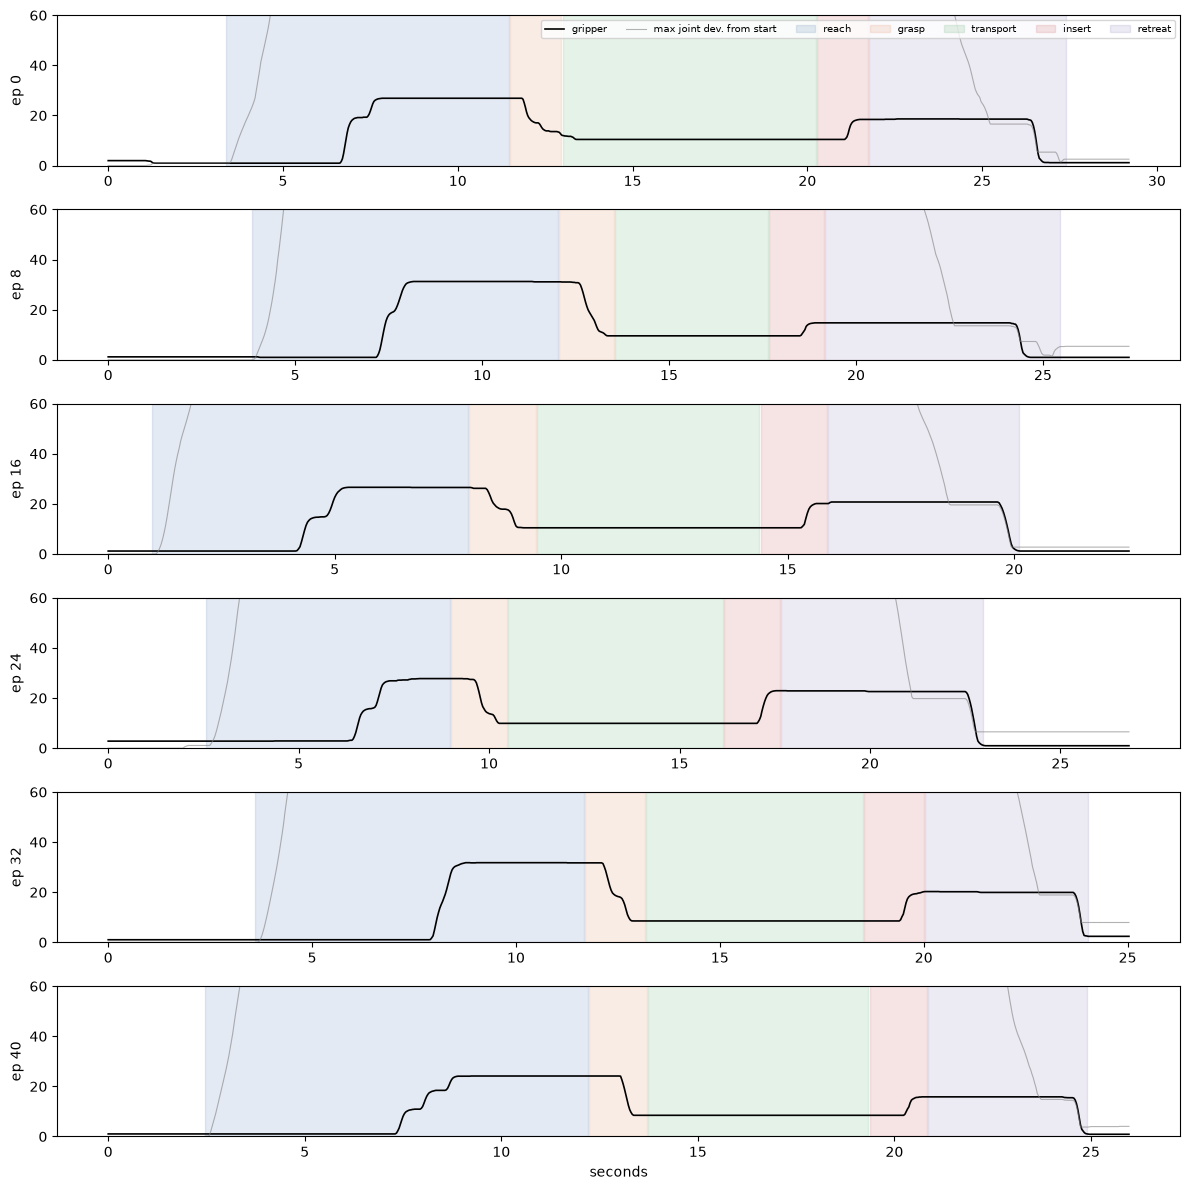

In [5]:
# ---- 1d. Visual check: gripper + joint motion with the trim window and phase boundaries.
# Look for: shaded window starts just before motion and ends just after it; grasp line where the gripper
# closes on the cylinder; release line where it opens again.
show = EPISODES[:: max(1, len(EPISODES) // 6)][:6]
fig, axes = plt.subplots(len(show), 1, figsize=(12, 2.0 * len(show)), sharex=False)
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]
for ax, ep in zip(np.atleast_1d(axes), show):
    d = EP[ep]; T = len(d["state"]); t = np.arange(T) / 30
    ax.plot(t, d["state"][:, 5], "k", lw=1.2, label="gripper")
    ax.plot(t, np.abs(d["state"] - d["state"][0]).max(1), color="gray", lw=0.8, alpha=0.6, label="max joint dev. from start")
    for p in range(5):
        m = d["phase"] == p
        if m.any(): ax.axvspan(t[m][0], t[m][-1], color=colors[p], alpha=0.15, label=PHASES[p])
    ax.set_ylabel(f"ep {ep}"); ax.set_ylim(0, 60)
np.atleast_1d(axes)[0].legend(ncol=7, fontsize=7, loc="upper right")
np.atleast_1d(axes)[-1].set_xlabel("seconds")
plt.tight_layout(); plt.show()

In [6]:
# ---- 1e. Sample frames + action targets
# Two action targets per sampled frame t (both 6-d):
#   motion  = action[t + HORIZON] - state[t]   "where the arm is told to go in the next 1/3 s"  (PRIMARY)
#   absolute = action[t]                       what 07 used; nearly equals the current pose, so any
#                                              space that encodes the pose looks consistent -> secondary
rows = []
for ep in EPISODES:
    d = EP[ep]; t0, t1 = d["t0"], d["t1"]
    ts = np.unique(np.linspace(t0, t1, min(FRAMES_PER_EPISODE, t1 - t0 + 1)).round().astype(int))
    for t in ts:
        tf = min(t + HORIZON, t1)
        rows.append(dict(ep=ep, frame=t, gidx=int(d["gidx"][t]), phase=int(d["phase"][t]),
                         time_frac=(t - t0) / max(1, t1 - t0),
                         state=d["state"][t], action=d["action"][t],
                         motion=d["action"][tf] - d["state"][t]))
S = pd.DataFrame(rows)
episodes = S.ep.to_numpy(); phase = S.phase.to_numpy(); time_frac = S.time_frac.to_numpy()
states  = np.stack(S.state); act_abs = np.stack(S.action); act_mot = np.stack(S.motion)
print(f"sampled {len(S)} frames; per phase:", {PHASES[p]: int((phase == p).sum()) for p in range(5)},
      "| unknown:", int((phase == -1).sum()))

sampled 4000 frames; per phase: {'reach': 1444, 'grasp': 281, 'transport': 1078, 'insert': 277, 'retreat': 920} | unknown: 0


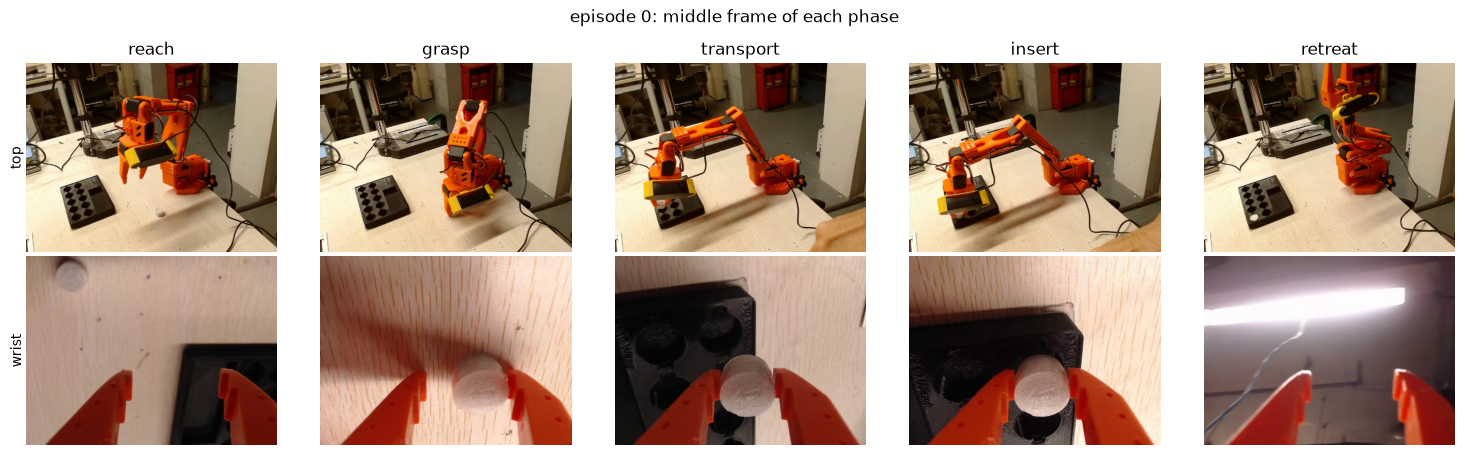

In [7]:
# ---- 1f. Open the dataset for image decoding (used in Sections 2 and 6) and look at the two cameras at each phase for one episode: do the phases make sense?
from lerobot.datasets.lerobot_dataset import LeRobotDataset
ds = LeRobotDataset(REPO_ID, root=DATASET_ROOT)

def frame_images(gidx):
    item = ds[int(gidx)]
    return [item[f"observation.images.{c}"].clamp(0, 1).permute(1, 2, 0).numpy() for c in CAMS]

ep = EPISODES[0]; d = EP[ep]
fig, ax = plt.subplots(2, 5, figsize=(15, 4.6))
for p in range(5):
    fr = np.flatnonzero(d["phase"] == p)
    if len(fr) == 0: continue
    imgs = frame_images(d["gidx"][fr[len(fr) // 2]])     # middle frame of the phase
    for r in range(2):
        ax[r, p].imshow(imgs[r]); ax[r, p].axis("off")
    ax[0, p].set_title(PHASES[p])
ax[0, 0].text(-40, 240, "top", rotation=90, va="center"); ax[1, 0].text(-40, 240, "wrist", rotation=90, va="center")
plt.suptitle(f"episode {ep}: middle frame of each phase"); plt.tight_layout(); plt.show()

## Section 2 — Embed both cameras with DINOv2  *(cached)*

DINOv2 turns each 640×480 image into a 384-number vector that summarizes *what is in the image*; images that
look alike get vectors pointing in similar directions. Each vector is **L2-normalized** (length 1), so
"how different are two images" = **cosine distance** = 1 − dot product (0 = same, ~1 = unrelated).

> **If the model download stalls:** the proxy settings in Section 0 must run *before* this section imports `transformers`. If it already stalled, restart the kernel and run from the top, or uncomment `HF_HUB_OFFLINE` in Section 0 to use the copy already in the cache.

The same sampled frames are embedded for both cameras, so every comparison later is **paired**: identical
frames, identical actions, only the observation space changes. The cache is keyed on the config, so
changing sampling or trimming recomputes automatically.

In [8]:
import torch
from transformers import AutoImageProcessor, AutoModel
from tqdm.auto import tqdm

cfg_key = hashlib.md5(json.dumps(dict(r=REPO_ID, m=DINO_MODEL, n=FRAMES_PER_EPISODE, tt=TRIM_THRESH, tp=TRIM_PAD,
                                      g=[int(x) for x in S.gidx])).encode()).hexdigest()
if os.path.exists(CACHE) and str(np.load(CACHE)["cfg_key"]) == cfg_key:
    Z = np.load(CACHE); EMB = {c: Z[f"emb_{c}"] for c in CAMS}
    print("loaded cache:", CACHE)
else:
    proc  = AutoImageProcessor.from_pretrained(DINO_MODEL)
    model = AutoModel.from_pretrained(DINO_MODEL).to(DEVICE).eval()

    @torch.no_grad()
    def embed(batch):                                    # batch: (B,3,H,W) float in [0,1]
        inp = proc(images=list(batch), return_tensors="pt", do_rescale=False).to(DEVICE)
        out = model(**inp)
        emb = out.pooler_output if getattr(out, "pooler_output", None) is not None else out.last_hidden_state[:, 0]
        return torch.nn.functional.normalize(emb, dim=-1).cpu().numpy()   # unit length -> cosine-ready

    EMB = {c: [] for c in CAMS}; buf = {c: [] for c in CAMS}; B = 32
    for j, gi in enumerate(tqdm(S.gidx, desc="decode + embed")):
        item = ds[int(gi)]                               # decodes both camera frames for this timestep
        for c in CAMS: buf[c].append(item[f"observation.images.{c}"].clamp(0, 1))
        if len(buf[CAMS[0]]) == B or j == len(S) - 1:
            for c in CAMS: EMB[c].append(embed(torch.stack(buf[c]))); buf[c] = []
    EMB = {c: np.concatenate(v).astype(np.float32) for c, v in EMB.items()}
    np.savez_compressed(CACHE, cfg_key=cfg_key, **{f"emb_{c}": v for c, v in EMB.items()})
    print("saved ->", CACHE)
print({c: v.shape for c, v in EMB.items()})

loaded cache: /home/bj/Documents/bingjian/robot_learning/smolvla_so101/phase05_cache.npz
{'top': (4000, 384), 'wrist': (4000, 384)}


## Section 3 — Action divergence in every observation space

**Spaces compared** (all built from the same frames):

| Space | What it is | Role |
|---|---|---|
| `top`, `wrist` | one camera's embedding | single views |
| `top+wrist` | both embeddings side by side, scaled by 1/√2 | the candidate. Its cosine distance = the **average** of the two cameras' distances, so each camera counts equally |
| `top+shuffled wrist` | top + a wrist embedding from a **random other frame** | **control**: same size and value range, but no matching information. Averaged over `N_SHUFFLE` shuffles |
| `top+top` | top next to a copy of itself | **sanity check**: mathematically identical neighbors to `top`, so identical numbers. If not, something is broken |
| `state` | z-scored joint positions | reference: what proprioception alone knows |

**The divergence of frame *i*** (for a given space and k):
1. distance from *i* to every other sampled frame (cosine for images, Euclidean for joints);
2. **ignore frames from the same episode** — those are the same moment a fraction of a second away and
   would always agree;
3. take the *k* nearest remaining frames;
4. spread of their action targets = √(mean over the 6 joints of the variance across the *k* neighbors);
5. divide by the same spread computed over **all** frames → 0 = neighbors agree, 1 = no better than random.

Actions are divided by each joint's std first, so the gripper and big joints weigh equally.

In [9]:
def zscore(X): return (X - X.mean(0)) / (X.std(0) + 1e-6)

def cross_episode_knn(X, k, metric):
    """Indices of the k nearest neighbors of every row, excluding rows from the same episode."""
    if metric == "cosine":                      # rows are unit length (or concatenations scaled to unit length)
        D = 1.0 - X @ X.T
    else:
        sq = (X ** 2).sum(1)
        D = sq[:, None] + sq[None, :] - 2 * X @ X.T
    D[episodes[:, None] == episodes[None, :]] = np.inf      # same episode (incl. itself) can't be a neighbor
    return np.argpartition(D, k, axis=1)[:, :k]             # (M,k) unordered k smallest

def divergence(nbr_idx, Y):
    """Per-frame spread of Y among its neighbors, relative to the global spread. Y is z-scored per dim."""
    local = np.sqrt(Y[nbr_idx].var(axis=1).mean(axis=1))    # (M,) neighbors' action spread
    return local / np.sqrt(Y.var(axis=0).mean())

rng = np.random.default_rng(0)
cat = lambda a, b: np.concatenate([a, b], axis=1) / np.sqrt(2)    # unit length again
SPACES = {
    "top":       (EMB["top"], "cosine"),
    "wrist":     (EMB["wrist"], "cosine"),
    "top+wrist": (cat(EMB["top"], EMB["wrist"]), "cosine"),
    "top+top":   (cat(EMB["top"], EMB["top"]), "cosine"),
    "state":     (zscore(states), "euclidean"),
}
SHUFFLED = [cat(EMB["top"], EMB["wrist"][rng.permutation(len(S))]) for _ in range(N_SHUFFLE)]
TARGETS = {"motion": zscore(act_mot), "absolute": zscore(act_abs)}

# DIV[target][space][k] -> (M,) per-frame divergence
DIV = {t: {s: {} for s in list(SPACES) + ["top+shuffled wrist"]} for t in TARGETS}
NBR = {}                                                     # neighbors at K_MAIN, reused in Section 6
for k in K_LIST:
    for s, (X, metric) in SPACES.items():
        idx = cross_episode_knn(X, k, metric)
        if k == K_MAIN: NBR[s] = idx
        for t, Y in TARGETS.items(): DIV[t][s][k] = divergence(idx, Y)
    shuf_idx = [cross_episode_knn(X, k, "cosine") for X in SHUFFLED]
    for t, Y in TARGETS.items():
        DIV[t]["top+shuffled wrist"][k] = np.mean([divergence(i, Y) for i in shuf_idx], axis=0)

ORDER = ["state", "top", "wrist", "top+wrist", "top+shuffled wrist", "top+top"]
summary = pd.DataFrame({(t, f"k={k}"): {s: DIV[t][s][k].mean() for s in ORDER} for t in TARGETS for k in K_LIST})
print("Mean action divergence (lower = the space tells apart states that need different actions)")
display(summary.round(3))
assert np.allclose(DIV["motion"]["top"][K_MAIN], DIV["motion"]["top+top"][K_MAIN], atol=1e-4), \
    "sanity check failed: top+top should equal top"
print("sanity check passed: top+top == top")

Mean action divergence (lower = the space tells apart states that need different actions)


motion               absolute              
                      k=5   k=10   k=20      k=5   k=10   k=20
state               0.457  0.520  0.569    0.093  0.116  0.144
top                 0.544  0.641  0.711    0.238  0.291  0.329
wrist               0.464  0.522  0.576    0.245  0.297  0.343
top+wrist           0.440  0.499  0.553    0.170  0.207  0.248
top+shuffled wrist  0.750  0.834  0.884    0.469  0.541  0.603
top+top             0.544  0.641  0.711    0.238  0.291  0.329

sanity check passed: top+top == top


## Section 4 — Pass test (H-c): does the wrist camera add real information?

For each k, two conditions, both required:
1. **gain** = divergence(top) − divergence(top+wrist) **> 0**: adding the wrist camera lowers divergence.
2. **beats control** = divergence(top+shuffled wrist) − divergence(top+wrist) **> 0**: the drop needs the
   *matching* wrist frame, not just 384 extra numbers.

Why both: extra embedding dimensions change the neighbor sets. If they happened to lower divergence on their
own, condition 2 catches it. Usually random dims *add noise* and raise divergence, so the control is then
above `top`; in that case condition 1 is the binding one. Subtracting the control from the gain would make
the test too easy.

**Uncertainty:** frames inside one episode are not independent, so we resample **whole episodes** with
replacement (bootstrap) and recompute the averages. The 95% interval is the middle 95% of those values.
(Neighbors are not recomputed per resample, so the interval is slightly optimistic.)

In [10]:
EP_IDS = np.array(EPISODES)
def episode_means(v):                                  # (n_episodes,) mean per episode
    return np.array([v[episodes == e].mean() for e in EP_IDS])

def boot_ci(ep_vals, n=N_BOOT, seed=0):
    r = np.random.default_rng(seed)
    draws = r.integers(0, len(ep_vals), size=(n, len(ep_vals)))
    b = ep_vals[draws].mean(axis=1)
    return ep_vals.mean(), np.percentile(b, 2.5), np.percentile(b, 97.5)

rows = []
for t in TARGETS:
    for k in K_LIST:
        top = episode_means(DIV[t]["top"][k]); tw = episode_means(DIV[t]["top+wrist"][k])
        ctl = episode_means(DIV[t]["top+shuffled wrist"][k]); wr = episode_means(DIV[t]["wrist"][k])
        gain, g_lo, g_hi = boot_ci(top - tw)                      # per-episode paired difference
        vs_ctl, c_lo, c_hi = boot_ci(ctl - tw)
        rows.append(dict(target=t, k=k, top=top.mean(), wrist=wr.mean(), top_wrist=tw.mean(), control=ctl.mean(),
                         gain=gain, gain_lo=g_lo, gain_hi=g_hi, vs_control=vs_ctl, vs_control_lo=c_lo,
                         passed=(g_lo > 0) and (c_lo > 0),
                         beats_both_views=tw.mean() < min(top.mean(), wr.mean())))
PASS = pd.DataFrame(rows)
with pd.option_context("display.max_columns", None, "display.width", 200):
    display(PASS.round(3))
prim = PASS[PASS.target == "motion"]
print("H-c PASS (motion target, every k, both CIs above 0):", bool(prim.passed.all()),
      "| top+wrist below both single views at every k:", bool(prim.beats_both_views.all()))

,target,k,top,wrist,top_wrist,control,gain,gain_lo,gain_hi,vs_control,vs_control_lo,passed,beats_both_views
0,motion,5,0.544,0.464,0.440,0.750,0.104,0.087,0.120,0.310,0.298,True,True
1,motion,10,0.641,0.522,0.499,0.834,0.142,0.127,0.156,0.335,0.324,True,True
2,motion,20,0.711,0.576,0.553,0.884,0.158,0.144,0.173,0.331,0.321,True,True
3,absolute,5,0.238,0.245,0.170,0.469,0.068,0.062,0.075,0.299,0.289,True,True
4,absolute,10,0.291,0.297,0.207,0.541,0.084,0.078,0.089,0.335,0.325,True,True
5,absolute,20,0.329,0.343,0.248,0.603,0.081,0.076,0.085,0.355,0.344,True,True


H-c PASS (motion target, every k, both CIs above 0): True | top+wrist below both single views at every k: True


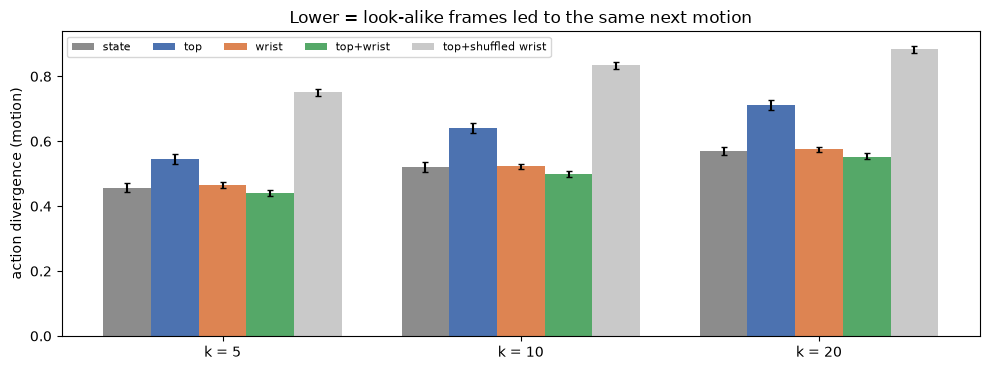

In [11]:
# Bars: divergence per space at each k (motion target), with episode-bootstrap 95% intervals
show_spaces = ["state", "top", "wrist", "top+wrist", "top+shuffled wrist"]
colors = {"state": "#8C8C8C", "top": "#4C72B0", "wrist": "#DD8452", "top+wrist": "#55A868", "top+shuffled wrist": "#C9C9C9"}
fig, ax = plt.subplots(figsize=(10, 3.8)); w = 0.16
for i, s in enumerate(show_spaces):
    for j, k in enumerate(K_LIST):
        m, lo, hi = boot_ci(episode_means(DIV["motion"][s][k]))
        ax.bar(j + (i - 2) * w, m, w, color=colors[s], label=s if j == 0 else None,
               yerr=[[m - lo], [hi - m]], capsize=2)
ax.set_xticks(range(len(K_LIST))); ax.set_xticklabels([f"k = {k}" for k in K_LIST])
ax.set_ylabel("action divergence (motion)"); ax.legend(fontsize=8, ncol=5)
ax.set_title("Lower = look-alike frames led to the same next motion")
plt.tight_layout(); plt.show()

## Section 5 — Where in the task does each view help? (H-a, H-b, H-e)

Same divergence (motion target, k = `K_MAIN`), averaged **within each phase**. What to look for:
- **H-a:** in `grasp` and `insert`, the wrist line is below the top line.
- **H-b:** in `reach`, the top line is below the wrist line.
- **H-e:** the state line is highest in `reach` (same home pose, 10 different targets) and drops later.
- **H-c by phase:** top+wrist should sit at or below the lower of top and wrist in every phase.

,reach,grasp,transport,insert,retreat
state,0.580,0.531,0.465,0.485,0.499
top,0.742,0.477,0.605,0.484,0.620
wrist,0.562,0.471,0.497,0.482,0.517
top+wrist,0.553,0.469,0.440,0.494,0.494
top+shuffled wrist,0.943,0.742,0.733,0.531,0.900


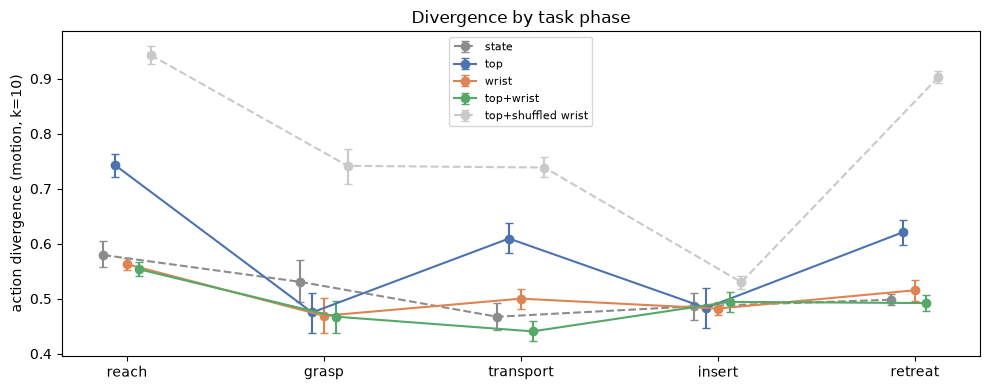

H-a  wrist < top in grasp & insert: True
H-b  top < wrist in reach:         False
H-e  state highest in reach, and above top there: False


In [12]:
known = phase >= 0
tab = {}
for s in show_spaces:
    v = DIV["motion"][s][K_MAIN]
    tab[s] = [v[known & (phase == p)].mean() for p in range(5)]
PH = pd.DataFrame(tab, index=PHASES).T
display(PH.round(3))

# episode-bootstrap interval per (space, phase)
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(5)
for i, s in enumerate(show_spaces):
    v = DIV["motion"][s][K_MAIN]; mean, lo, hi = [], [], []
    for p in range(5):
        ep_vals = np.array([v[(episodes == e) & (phase == p)].mean() for e in EP_IDS if ((episodes == e) & (phase == p)).any()])
        m_, l_, h_ = boot_ci(ep_vals) if len(ep_vals) else (np.nan,) * 3
        mean.append(m_); lo.append(m_ - l_); hi.append(h_ - m_)
    ax.errorbar(x + (i - 2) * 0.06, mean, yerr=[lo, hi], marker="o", capsize=3, color=colors[s], label=s,
                ls="--" if s in ("state", "top+shuffled wrist") else "-")
ax.set_xticks(x); ax.set_xticklabels(PHASES); ax.set_ylabel(f"action divergence (motion, k={K_MAIN})")
ax.set_title("Divergence by task phase"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

print("H-a  wrist < top in grasp & insert:", bool(PH.loc["wrist", "grasp"] < PH.loc["top", "grasp"]
                                                   and PH.loc["wrist", "insert"] < PH.loc["top", "insert"]))
print("H-b  top < wrist in reach:        ", bool(PH.loc["top", "reach"] < PH.loc["wrist", "reach"]))
print("H-e  state highest in reach, and above top there:",
      bool(PH.loc["state"].idxmax() == "reach" and PH.loc["state", "reach"] > PH.loc["top", "reach"]))

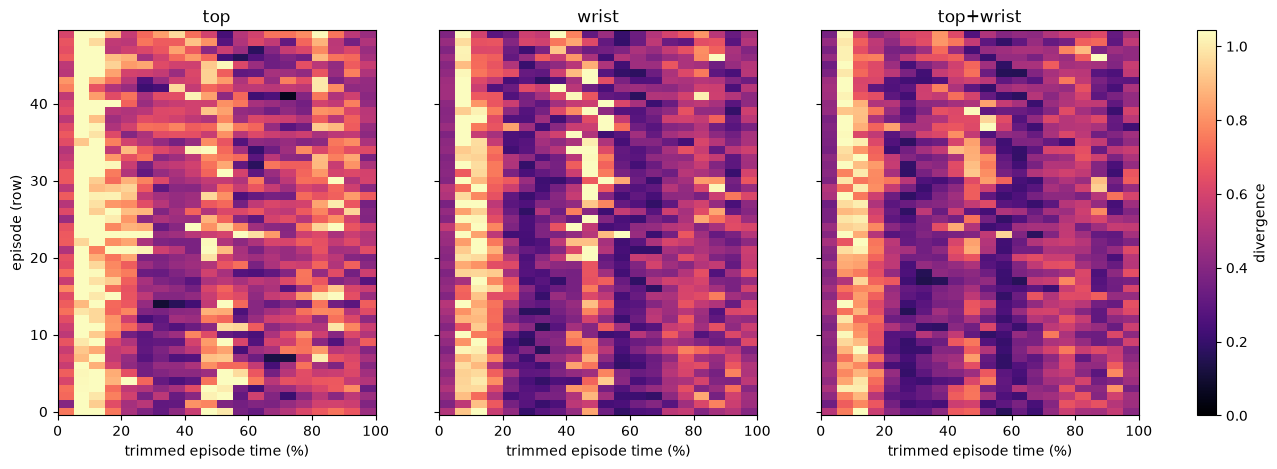

In [13]:
# Finer time view: episode x normalized-time heatmaps for top, wrist, top+wrist (shared color scale)
N_BINS = 20
def heat(v):
    H = np.full((len(EP_IDS), N_BINS), np.nan); b = np.clip((time_frac * N_BINS).astype(int), 0, N_BINS - 1)
    for r, e in enumerate(EP_IDS):
        for c in range(N_BINS):
            m = (episodes == e) & (b == c)
            if m.any(): H[r, c] = v[m].mean()
    return H
Hs = {s: heat(DIV["motion"][s][K_MAIN]) for s in ["top", "wrist", "top+wrist"]}
vmax = np.nanpercentile(np.concatenate([h.ravel() for h in Hs.values()]), 95)
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for a, (s, H) in zip(ax, Hs.items()):
    im = a.imshow(H, aspect="auto", origin="lower", cmap="magma", vmin=0, vmax=vmax, extent=[0, 100, -0.5, len(EP_IDS) - 0.5])
    a.set_title(s); a.set_xlabel("trimmed episode time (%)")
ax[0].set_ylabel("episode (row)"); fig.colorbar(im, ax=ax, fraction=0.02, label="divergence")
plt.show()

## Section 6 — Aliasing (H-d): look-alike from above, different up close

For every frame *i* and each of its `K_MAIN` nearest **top-camera** neighbors *j* (other episodes), the pair is
**aliased** when both hold:
- **far in wrist space:** wrist cosine distance(i, j) is above the median over random cross-episode pairs;
- **different next motion:** motion distance(i, j) is above the median over random cross-episode pairs.

That is: the top camera says "same situation", the wrist camera says "different situation", and the operator
indeed did something different. The **reverse** count (close in wrist, far in top) is shown too — H-b predicts
it is higher during `reach`.

Fraction of each frame's 10 nearest neighbors that are aliased (by phase of the frame)


,all,reach,grasp,transport,insert,retreat
pairs,,,,,,
close top / far wrist,0.006,0.005,0.000,0.010,0.000,0.008
close wrist / far top,0.008,0.005,0.019,0.014,0.005,0.005


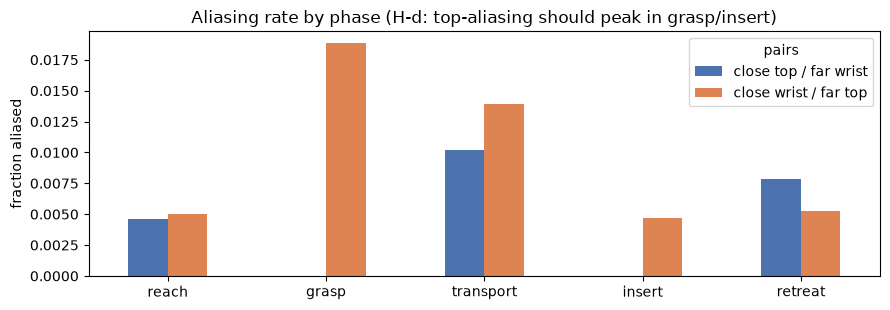

In [14]:
Ym = TARGETS["motion"]
r = np.random.default_rng(1)
a_, b_ = r.integers(0, len(S), 20000), r.integers(0, len(S), 20000)
keep = episodes[a_] != episodes[b_]; a_, b_ = a_[keep], b_[keep]
cos_d = lambda E, i, j: 1.0 - (E[i] * E[j]).sum(-1)
MED = dict(top=np.median(cos_d(EMB["top"], a_, b_)), wrist=np.median(cos_d(EMB["wrist"], a_, b_)),
           motion=np.median(np.linalg.norm(Ym[a_] - Ym[b_], axis=1)))

def alias_pairs(near_space, far_space):
    i = np.repeat(np.arange(len(S)), K_MAIN); j = NBR[near_space].ravel()
    far = cos_d(EMB[far_space], i, j) > MED[far_space]
    diff = np.linalg.norm(Ym[i] - Ym[j], axis=1) > MED["motion"]
    return i, j, far & diff

rows = []
for name, (near, far) in {"close top / far wrist": ("top", "wrist"), "close wrist / far top": ("wrist", "top")}.items():
    i, j, al = alias_pairs(near, far)
    rows.append({"pairs": name, "all": al.mean(), **{PHASES[p]: al[phase[i] == p].mean() for p in range(5)}})
ALIAS = pd.DataFrame(rows).set_index("pairs")
print(f"Fraction of each frame's {K_MAIN} nearest neighbors that are aliased (by phase of the frame)")
display(ALIAS.round(3))
ALIAS[PHASES].T.plot(kind="bar", figsize=(9, 3.2), color=["#4C72B0", "#DD8452"], rot=0,
                     title="Aliasing rate by phase (H-d: top-aliasing should peak in grasp/insert)")
plt.ylabel("fraction aliased"); plt.tight_layout(); plt.show()

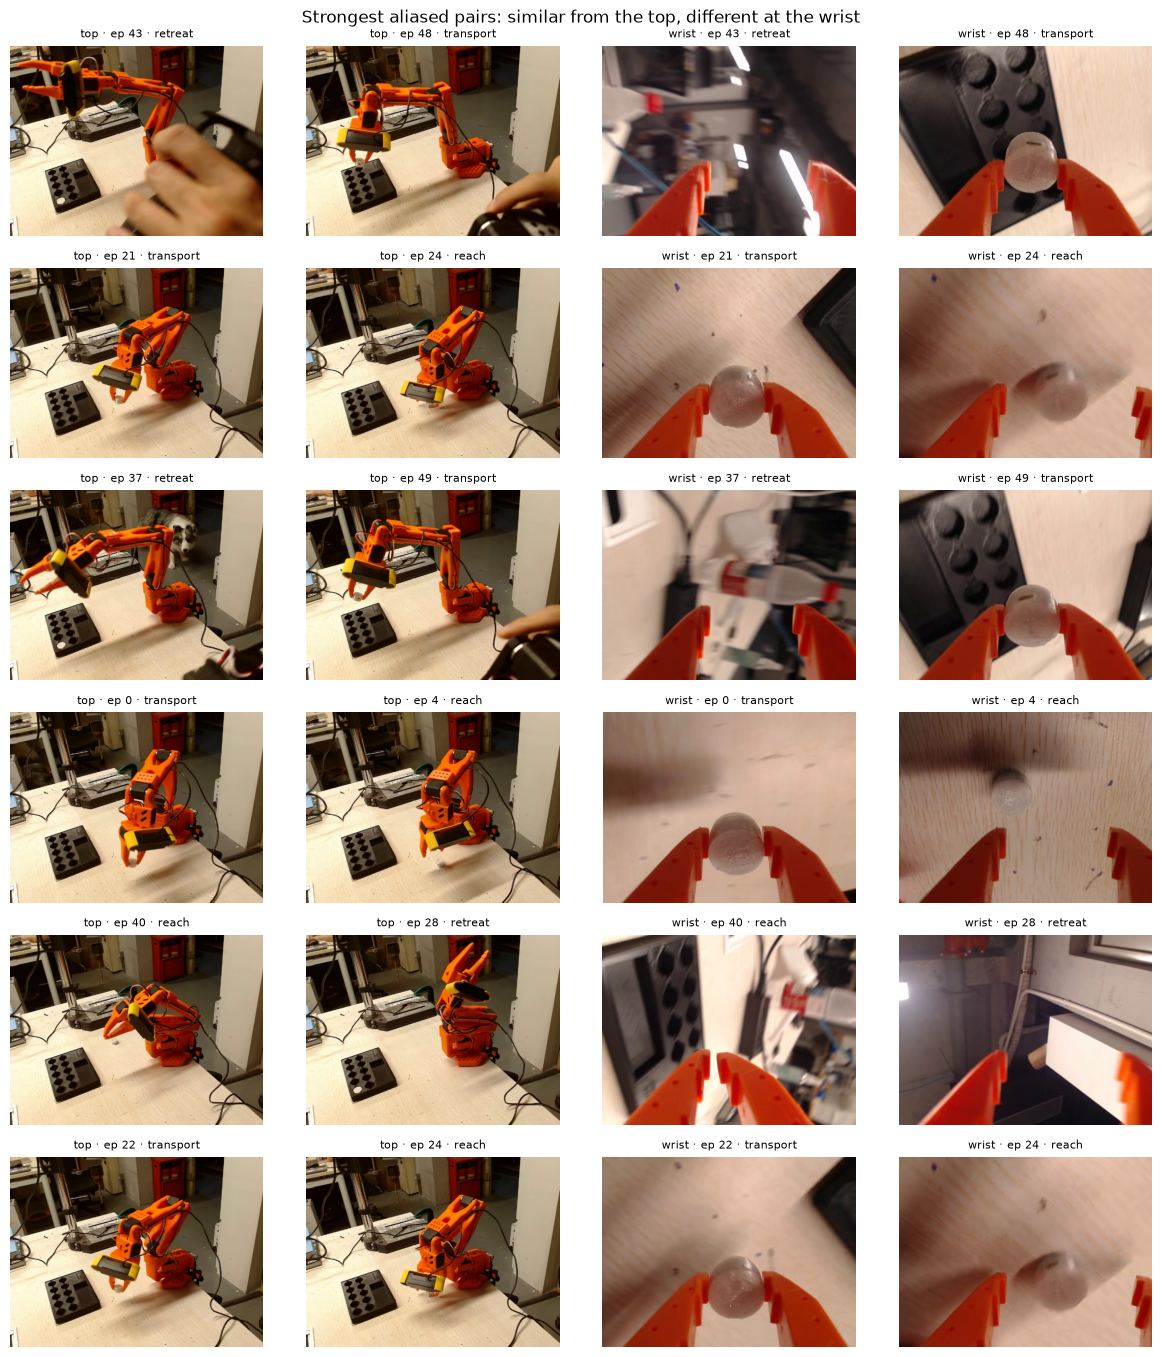

In [15]:
# Show the strongest top-aliased pairs: each row = one pair. If H-d is right, the two TOP images look alike,
# the two WRIST images clearly differ (e.g. gripper offset from the cylinder), and the motions differ.
i, j, al = alias_pairs("top", "wrist")
score = cos_d(EMB["wrist"], i, j) * np.linalg.norm(Ym[i] - Ym[j], axis=1)
score[~al] = -1
order = np.argsort(-score); seen, picks = set(), []
for o in order:                                          # one pair per source episode, for variety
    if score[o] < 0 or len(picks) == 6: break
    if episodes[i[o]] in seen: continue
    seen.add(episodes[i[o]]); picks.append((i[o], j[o]))

fig, ax = plt.subplots(len(picks), 4, figsize=(12, 2.3 * max(1, len(picks))), squeeze=False)
for r_, (a, b) in enumerate(picks):
    ia, ib = frame_images(S.gidx[a]), frame_images(S.gidx[b])
    for c_, (img, lbl) in enumerate([(ia[0], "top"), (ib[0], "top"), (ia[1], "wrist"), (ib[1], "wrist")]):
        e_ = episodes[a] if c_ % 2 == 0 else episodes[b]; p_ = phase[a] if c_ % 2 == 0 else phase[b]
        ax[r_, c_].imshow(img); ax[r_, c_].axis("off")
        ax[r_, c_].set_title(f"{lbl} · ep {e_} · {PHASES[p_] if p_ >= 0 else '?'}", fontsize=8)
plt.suptitle("Strongest aliased pairs: similar from the top, different at the wrist"); plt.tight_layout(); plt.show()

## Section 7 — Visual diversity (H-f, descriptive)

Mean pairwise cosine distance between sampled frames: how spread out the frames are in each space.
**Caveat:** different cameras have differently shaped embedding clouds, so "wrist 0.4 vs top 0.2" is a hint,
not a measurement on one scale. Diversity is also not automatically good (07): a varied space only helps if
Section 4 shows it separates frames that need different actions.

,all,reach,grasp,transport,insert,retreat
top,0.186,0.178,0.163,0.133,0.064,0.163
wrist,0.468,0.415,0.249,0.231,0.157,0.469
top+wrist,0.327,0.297,0.206,0.182,0.110,0.316


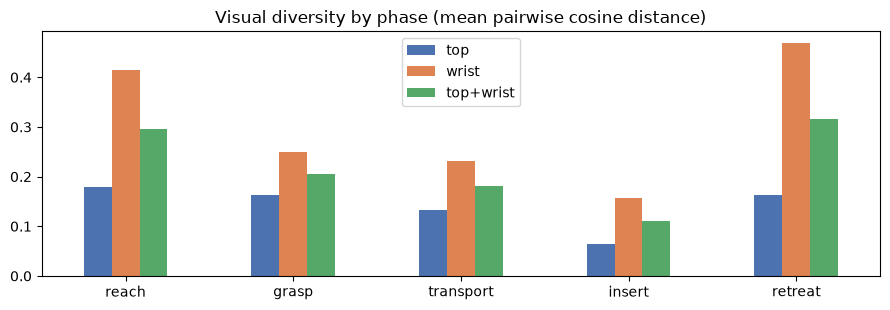

H-f  wrist diversity > top: True


In [16]:
def mean_pairwise_cos(E, mask, cap=2000, seed=0):
    idx = np.flatnonzero(mask); r = np.random.default_rng(seed)
    if len(idx) > cap: idx = r.choice(idx, cap, replace=False)
    D = 1.0 - E[idx] @ E[idx].T
    return float(D[np.triu_indices(len(idx), 1)].mean())

DSP = {"top": EMB["top"], "wrist": EMB["wrist"], "top+wrist": cat(EMB["top"], EMB["wrist"])}
DIVERSITY = pd.DataFrame({s: {"all": mean_pairwise_cos(E, np.ones(len(S), bool)),
                              **{PHASES[p]: mean_pairwise_cos(E, phase == p) for p in range(5)}}
                          for s, E in DSP.items()}).T
display(DIVERSITY.round(3))
DIVERSITY[PHASES].T.plot(kind="bar", figsize=(9, 3.2), rot=0, color=["#4C72B0", "#DD8452", "#55A868"],
                         title="Visual diversity by phase (mean pairwise cosine distance)")
plt.tight_layout(); plt.show()
print("H-f  wrist diversity > top:", bool(DIVERSITY.loc["wrist", "all"] > DIVERSITY.loc["top", "all"]))

## Section 8 — How to read the results

| Result | Supports | Refutes / what it would mean |
|---|---|---|
| Section 4: `passed` True at every k (motion) | **H-c**: the wrist camera adds information that separates states needing different motions | `gain_lo` ≤ 0 → the top camera already sees enough for this task. `vs_control_lo` ≤ 0 → extra dims alone explain the drop |
| Section 5: wrist < top in grasp/insert | **H-a** | wrist ≥ top there → the wrist view is blurred, occluded by the cylinder, or mis-aimed; check the Section 6 images |
| Section 5: top < wrist in reach | **H-b** | wrist ≤ top in reach → the cylinder is already visible to the wrist camera early (good for policies, but H-b is wrong) |
| Section 5: state highest in reach | **H-e** | state flat → start positions don't really differ, or the operator took the same path to every position |
| Section 6: top-aliasing peaks in grasp/insert, and pairs look right by eye | **H-d** | uniform aliasing across phases → likely embedding noise, not real aliasing |
| Section 7: wrist > top | **H-f** (descriptive) | — |

**Cross-checks before believing a result**
- `top+top` equals `top` (asserted in Section 3).
- The `absolute` rows should rank the spaces the same way; if only `motion` shows the effect, say so.
- The effect should hold at k = 5, 10 and 20; a result that only appears at one k is fragile.
- Section 1d plots: trimming and phases look right for the plotted episodes.

Write the C1 result into 08 §A.4 (Phase 0.5): pass/fail, gain with CI at each k, and which phases drive it.

---
# Follow-ups (added 2026-09-19 after the first full run)

Results of the first run: [Details/phase05_camera_test_results.md](Details/phase05_camera_test_results.md).
Sections 0–8 above are unchanged; everything below is new and reuses the variables they defined, so run
the notebook top to bottom.

## Section 9 — Divergence normalized *within* each phase

**The problem this fixes.** Section 5 divides every phase by the spread of motions over the *whole*
dataset. During grasp and insert the arm barely moves, so the local spread is small for every space and
all curves drop together — that is arithmetic, not information. Two changes here:

1. **Phase-local scale:** divide by the spread of motions *within that phase*, so 1.0 always means
   "no better than not looking".
2. **Neighbors from the same phase only** (second table): the hardest and most policy-relevant question is
   whether a view separates states *inside* one stage of the task, not whether it can tell reach from
   transport.

A **random baseline** is drawn as a dashed line: k random frames from the same phase and other episodes.
It lands slightly below 1.0 (a k-sample underestimates variance), so that line, not 1.0, is the "knows
nothing" level.

In [ ]:
# ---- 9a. Helpers: distance matrix, masked neighbors, phase-normalized divergence
SAME_EP = episodes[:, None] == episodes[None, :]
SAME_PH = phase[:, None] == phase[None, :]
Ymot = TARGETS["motion"]

def dist_matrix(X, metric):
    if metric == "cosine":                       # rows are unit length -> cosine distance
        D = 1.0 - X @ X.T
    else:
        sq = (X ** 2).sum(1); D = sq[:, None] + sq[None, :] - 2 * X @ X.T
    return D.astype(np.float32)

def knn_idx(X, metric="cosine", k=K_MAIN, within_phase=False):
    """k nearest neighbors from OTHER episodes; optionally restricted to the same phase."""
    D = dist_matrix(X, metric)
    D[SAME_EP] = np.inf                          # never compare a frame with its own episode
    if within_phase: D[~SAME_PH] = np.inf        # ... and keep the comparison inside one stage
    return np.argpartition(D, k, axis=1)[:, :k]

# scale factor per phase = spread of the next-motion vectors inside that phase
phase_scale = np.array([np.sqrt(Ymot[phase == p].var(0).mean()) for p in range(5)])
print("motion spread per phase:", dict(zip(PHASES, phase_scale.round(3))))

def div_phase_norm(idx, Y=Ymot):
    """Per-frame neighbor spread divided by the spread inside the frame's own phase."""
    return np.sqrt(Y[idx].var(axis=1).mean(axis=1)) / phase_scale[phase]

def random_same_phase_idx(k=K_MAIN, seed=0):
    r = np.random.default_rng(seed); out = np.zeros((len(S), k), int)
    for p in range(5):
        pool = np.flatnonzero(phase == p); rows = np.flatnonzero(phase == p)
        for i in rows:
            cand = pool[episodes[pool] != episodes[i]]
            out[i] = r.choice(cand, k, replace=False)
    return out
RAND_IDX = random_same_phase_idx()

In [ ]:
# ---- 9b. Two tables: neighbors from anywhere vs neighbors from the same phase
SPACES9 = {s: v for s, v in SPACES.items() if s != "top+top"}

def phase_table(within_phase):
    rows = {}
    for s, (X, metric) in SPACES9.items():
        d = div_phase_norm(knn_idx(X, metric, K_MAIN, within_phase))
        rows[s] = [d[phase == p].mean() for p in range(5)]
    rows["random (baseline)"] = [div_phase_norm(RAND_IDX)[phase == p].mean() for p in range(5)]
    return pd.DataFrame(rows, index=PHASES).T

PH_ANY, PH_IN = phase_table(False), phase_table(True)
print("A) neighbors from any phase, phase-normalized:"); display(PH_ANY.round(3))
print("B) neighbors from the SAME phase only (within-phase discrimination):"); display(PH_IN.round(3))

fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for a, (tab, title) in zip(ax, [(PH_ANY, "A) neighbors from any phase"), (PH_IN, "B) same-phase neighbors")]):
    x = np.arange(5)
    for i, s in enumerate(SPACES9):
        a.errorbar(x + (i - 1.5) * 0.05, tab.loc[s], marker="o", color=colors.get(s, "k"), label=s,
                   ls="--" if s in ("state", "top+shuffled wrist") else "-")
    a.plot(x, tab.loc["random (baseline)"], "k:", lw=1.5, label="random (knows nothing)")
    a.set_xticks(x); a.set_xticklabels(PHASES); a.set_title(title)
ax[0].set_ylabel("divergence ÷ spread inside the phase"); ax[0].legend(fontsize=8)
plt.suptitle("Phase-normalized action divergence (1.0 = no information)"); plt.tight_layout(); plt.show()

print("H-a (wrist < top in grasp & insert), same-phase neighbors:",
      bool(PH_IN.loc["wrist", "grasp"] < PH_IN.loc["top", "grasp"] and PH_IN.loc["wrist", "insert"] < PH_IN.loc["top", "insert"]))
print("H-b (top < wrist in reach), same-phase neighbors:", bool(PH_IN.loc["top", "reach"] < PH_IN.loc["wrist", "reach"]))

## Section 10 — What does each view add *on top of joint state*, and does the weighting matter?

Two questions the first run left open:

- **Does a camera add anything over proprioception?** A policy always gets the joint state, so the honest
  question is `state+camera` vs `state`, not `camera` vs `state`.
- **Is the small top+wrist gain caused by equal weighting?** Concatenating two unit-length embeddings makes
  the distance the plain **average** of the two views' distances, so the weaker view gets half the vote. A
  weight sweep shows the cost of that choice.

Each block is scaled to unit length and multiplied by √w, so the cosine distance of the combination is the
**w-weighted average** of the blocks' distances. The joint-state block is unit-normalized too, which drops
the magnitude of the pose vector — it makes the blocks comparable, at the cost of some information.

In [ ]:
# ---- 10a. Weighted blends of unit-length blocks
def unit(X): return X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-9)
U = {"top": EMB["top"], "wrist": EMB["wrist"], "state": unit(zscore(states))}

def blend(parts):
    """parts: {name: weight}, weights sum to 1 -> cosine distance = weighted avg of block distances."""
    w = np.array(list(parts.values()), float); w = w / w.sum()
    return np.concatenate([np.sqrt(wi) * U[n] for n, wi in zip(parts, w)], axis=1)

COMBOS = {
    "state": {"state": 1}, "top": {"top": 1}, "wrist": {"wrist": 1},
    "state+top": {"state": .5, "top": .5}, "state+wrist": {"state": .5, "wrist": .5},
    "top+wrist": {"top": .5, "wrist": .5}, "state+top+wrist": {"state": 1/3, "top": 1/3, "wrist": 1/3},
}
rows = []
for name, parts in COMBOS.items():
    X = blend(parts)
    r = dict(space=name)
    for k in K_LIST:
        r[f"k={k}"] = divergence(knn_idx(X, "cosine", k), Ymot).mean()
    r["within-phase (k=%d)" % K_MAIN] = div_phase_norm(knn_idx(X, "cosine", K_MAIN, within_phase=True)).mean()
    rows.append(r)
BLEND = pd.DataFrame(rows).set_index("space")
print("Divergence of blended spaces (motion target). Compare each state+X row with the state row.")
display(BLEND.round(3))

In [ ]:
# ---- 10b. Weight sweep: how much of the wrist advantage does equal weighting throw away?
ws = np.round(np.linspace(0, 1, 11), 2)
sweep = {"top vs wrist": [], "with state (1/3 fixed)": []}
for w in ws:
    sweep["top vs wrist"].append(divergence(knn_idx(blend({"top": w, "wrist": 1 - w}), "cosine", K_MAIN), Ymot).mean())
    sweep["with state (1/3 fixed)"].append(
        divergence(knn_idx(blend({"state": 1/3, "top": (2/3) * w, "wrist": (2/3) * (1 - w)}), "cosine", K_MAIN), Ymot).mean())
SW = pd.DataFrame(sweep, index=ws); SW.index.name = "weight on top"
best = SW["top vs wrist"].idxmin()
print(f"best top-weight without state: {best} (equal weighting = 0.5)"); display(SW.round(3))

fig, ax = plt.subplots(figsize=(8, 3.6))
for c in SW: ax.plot(ws, SW[c], marker="o", label=c)
ax.axvline(0.5, color="gray", ls=":", label="equal weighting (Sections 3-5)")
ax.set_xlabel("weight on top (0 = wrist only, 1 = top only)"); ax.set_ylabel(f"divergence (motion, k={K_MAIN})")
ax.legend(fontsize=8); ax.set_title("Cost of weighting the two cameras equally"); plt.tight_layout(); plt.show()

## Section 11 — Temporal context: does a short history disambiguate look-alike frames?

**Why.** A frame during *reach* and a frame during *transport* can look almost the same (same arm pose, the
cylinder small or hidden, sometimes motion blur), yet the next motion differs. What separates them is what
happened just before.

**How the order is encoded.** Each lag gets **its own block of dimensions**: `[e(t) , e(t−10) , e(t−20)]`.
Because "now" and "0.67 s ago" live in different blocks, they can never be confused — that slot layout *is*
a positional encoding, and swapping two lags gives a different vector. The distance is again the weighted
average of the per-lag distances, so `decayed` weighting lets the present frame count most.

Also built: **`+Δ`**, the current frame plus the *direction of change* `e(t) − e(t−20)` (unit-normalized).
That is an explicit motion feature: approaching an object and retreating from it give opposite Δ.

Only **relative** lags are used. Absolute episode time is deliberately not included: it would leak task
progress that a policy doesn't get, and would lower divergence for free.

In [ ]:
# ---- 11a. Embed the lagged frames (extra decode pass; cached in phase05_cache_hist.npz)
LAGS = [0, 10, 20]                      # frames back: now, 1/3 s ago, 2/3 s ago
HIST_CACHE = CACHE.replace(".npz", "_hist.npz")

# For each sampled frame, the dataset index of its lagged frames, clipped to the episode's trimmed start
lag_gidx = np.zeros((len(S), len(LAGS)), dtype=np.int64)
for i, (ep, fr) in enumerate(zip(S.ep, S.frame)):
    d = EP[ep]
    for j, L in enumerate(LAGS):
        lag_gidx[i, j] = d["gidx"][max(fr - L, d["t0"])]

hist_key = hashlib.md5(json.dumps(dict(m=DINO_MODEL, l=LAGS, g=lag_gidx.tolist())).encode()).hexdigest()
if os.path.exists(HIST_CACHE) and str(np.load(HIST_CACHE)["cfg_key"]) == hist_key:
    Zh = np.load(HIST_CACHE); HIST = {c: Zh[f"hist_{c}"] for c in CAMS}
    print("loaded", HIST_CACHE)
else:
    proc  = AutoImageProcessor.from_pretrained(DINO_MODEL)
    model = AutoModel.from_pretrained(DINO_MODEL).to(DEVICE).eval()

    @torch.no_grad()
    def embed(batch):
        inp = proc(images=list(batch), return_tensors="pt", do_rescale=False).to(DEVICE)
        out = model(**inp)
        emb = out.pooler_output if getattr(out, "pooler_output", None) is not None else out.last_hidden_state[:, 0]
        return torch.nn.functional.normalize(emb, dim=-1).cpu().numpy()

    need = np.unique(lag_gidx[:, 1:])                         # lag 0 is already in EMB
    look = {}                                                 # dataset index -> row in the new array
    buf, keys, out = [], [], {c: [] for c in CAMS}
    for j, gi in enumerate(tqdm(need, desc="decode + embed history frames")):
        item = ds[int(gi)]
        buf.append([item[f"observation.images.{c}"].clamp(0, 1) for c in CAMS]); keys.append(int(gi))
        if len(buf) == 32 or j == len(need) - 1:
            for ci, c in enumerate(CAMS): out[c].append(embed(torch.stack([b[ci] for b in buf])))
            buf = []
    E_lag = {c: np.concatenate(v).astype(np.float32) for c, v in out.items()}
    look = {g: i for i, g in enumerate(need)}
    HIST = {}
    for c in CAMS:                                            # (M, n_lags, 384)
        H = np.zeros((len(S), len(LAGS), E_lag[c].shape[1]), np.float32)
        H[:, 0] = EMB[c]
        for j in range(1, len(LAGS)):
            H[:, j] = E_lag[c][[look[g] for g in lag_gidx[:, j]]]
        HIST[c] = H
    np.savez_compressed(HIST_CACHE, cfg_key=hist_key, **{f"hist_{c}": v for c, v in HIST.items()})
    print("saved ->", HIST_CACHE)
print({c: v.shape for c, v in HIST.items()})

In [ ]:
# ---- 11b. Build history spaces and compare them with the single-frame versions
def stack_lags(cams, weights):
    """Concatenate one block per (camera, lag), each unit length, scaled by sqrt(weight)."""
    w = np.array(weights, float); w = w / (w.sum() * len(cams))
    return np.concatenate([np.sqrt(wi) * HIST[c][:, j] for c in cams for j, wi in enumerate(w)], axis=1)

def with_delta(cam):
    d = unit(HIST[cam][:, 0] - HIST[cam][:, -1])              # direction of change over the longest lag
    return np.concatenate([np.sqrt(.5) * HIST[cam][:, 0], np.sqrt(.5) * d], axis=1)

EQ, DEC = [1, 1, 1], [3, 2, 1]                                # equal slots vs. present-heavy weighting
TSPACES = {
    "top": EMB["top"], "top hist (equal)": stack_lags(["top"], EQ), "top hist (decayed)": stack_lags(["top"], DEC),
    "wrist": EMB["wrist"], "wrist hist (equal)": stack_lags(["wrist"], EQ), "wrist hist (decayed)": stack_lags(["wrist"], DEC),
    "wrist +Δ": with_delta("wrist"), "top +Δ": with_delta("top"),
    "top+wrist": cat(EMB["top"], EMB["wrist"]), "top+wrist hist (decayed)": stack_lags(["top", "wrist"], DEC),
}
rows = []
for name, X in TSPACES.items():
    r = dict(space=name)
    for k in K_LIST: r[f"k={k}"] = divergence(knn_idx(X, "cosine", k), Ymot).mean()
    idx_in = knn_idx(X, "cosine", K_MAIN, within_phase=True)
    r[f"within-phase (k={K_MAIN})"] = div_phase_norm(idx_in).mean()
    d_any = div_phase_norm(knn_idx(X, "cosine", K_MAIN))
    for p in (0, 2): r[f"{PHASES[p]} (any-nbr)"] = d_any[phase == p].mean()
    rows.append(r)
TEMP = pd.DataFrame(rows).set_index("space")
print("History vs single frame (lower is better). 'within-phase' is the strict test from Section 9B.")
display(TEMP.round(3))

fig, ax = plt.subplots(figsize=(11, 3.8))
x = np.arange(len(TEMP)); ax.bar(x - 0.2, TEMP[f"k={K_MAIN}"], 0.4, label=f"all neighbors (k={K_MAIN})")
ax.bar(x + 0.2, TEMP[f"within-phase (k={K_MAIN})"], 0.4, label="same-phase neighbors (phase-normalized)")
ax.set_xticks(x); ax.set_xticklabels(TEMP.index, rotation=25, ha="right"); ax.legend(fontsize=8)
ax.set_title("Does a short history help?"); plt.tight_layout(); plt.show()

## Section 12 — Is the top camera weak, or is the *embedding* weak?

The aliased pairs in Section 6 suggested the limit may be the representation rather than the camera: one
640×480 frame squeezed into a single global vector, where a grasped cylinder is a few pixels and the frame
is mostly unchanging background (shelves, wall, occasionally a person walking past).

Two cheap probes, both re-embedding the same sampled frames:
- **`dinov2-base`** (768-d, ~86M parameters) instead of `dinov2-small` (384-d, 22M): a stronger encoder.
- **cropped top**: cut the top view down to the work area before embedding, so the static background can't
  dominate. Check the preview and adjust `CROP` if it clips the arm or the fixture.

If cropping or the bigger model closes the gap to the wrist camera, the top view *does* carry the
information and our measurement was the bottleneck — which would also mean the C1 conclusion is about
embeddings as much as about cameras.

In [ ]:
# ---- 12a. Choose and preview the crop of the top view: (y0, y1, x0, x1) in pixels of the 480x640 frame
CROP = (150, 480, 0, 520)          # keep table + fixture + arm, drop shelves/wall/people
DINO_BIG = "facebook/dinov2-base"

y0, y1, x0, x1 = CROP
fig, ax = plt.subplots(2, 4, figsize=(14, 5))
for j, i in enumerate(np.linspace(0, len(S) - 1, 4).astype(int)):
    img = frame_images(S.gidx[i])[0]
    ax[0, j].imshow(img); ax[0, j].set_title(f"full · {PHASES[phase[i]]}", fontsize=9)
    ax[1, j].imshow(img[y0:y1, x0:x1]); ax[1, j].set_title("cropped", fontsize=9)
    for r in range(2): ax[r, j].axis("off")
plt.tight_layout(); plt.show()

In [ ]:
# ---- 12b. Re-embed: top cropped (small model) + both cameras with the bigger model
BIG_CACHE = CACHE.replace(".npz", "_big.npz")
big_key = hashlib.md5(json.dumps(dict(m=DINO_BIG, c=CROP, g=[int(x) for x in S.gidx])).encode()).hexdigest()
if os.path.exists(BIG_CACHE) and str(np.load(BIG_CACHE)["cfg_key"]) == big_key:
    Zb = np.load(BIG_CACHE); EMB2 = {k: Zb[k] for k in ["top_crop", "top_base", "wrist_base"]}
    print("loaded", BIG_CACHE)
else:
    proc_s = AutoImageProcessor.from_pretrained(DINO_MODEL)
    model_s = AutoModel.from_pretrained(DINO_MODEL).to(DEVICE).eval()
    proc_b = AutoImageProcessor.from_pretrained(DINO_BIG)
    model_b = AutoModel.from_pretrained(DINO_BIG).to(DEVICE).eval()

    @torch.no_grad()
    def emb_with(proc, model, batch):
        inp = proc(images=list(batch), return_tensors="pt", do_rescale=False).to(DEVICE)
        out = model(**inp)
        e = out.pooler_output if getattr(out, "pooler_output", None) is not None else out.last_hidden_state[:, 0]
        return torch.nn.functional.normalize(e, dim=-1).cpu().numpy()

    acc = {k: [] for k in ["top_crop", "top_base", "wrist_base"]}
    bt, bw = [], []
    for j, gi in enumerate(tqdm(S.gidx, desc="re-embed (crop + base model)")):
        item = ds[int(gi)]
        bt.append(item["observation.images.top"].clamp(0, 1)); bw.append(item["observation.images.wrist"].clamp(0, 1))
        if len(bt) == 16 or j == len(S) - 1:
            T, W = torch.stack(bt), torch.stack(bw)
            acc["top_crop"].append(emb_with(proc_s, model_s, T[:, :, y0:y1, x0:x1]))
            acc["top_base"].append(emb_with(proc_b, model_b, T))
            acc["wrist_base"].append(emb_with(proc_b, model_b, W))
            bt, bw = [], []
    EMB2 = {k: np.concatenate(v).astype(np.float32) for k, v in acc.items()}
    np.savez_compressed(BIG_CACHE, cfg_key=big_key, **EMB2)
    print("saved ->", BIG_CACHE)
print({k: v.shape for k, v in EMB2.items()})

In [ ]:
# ---- 12c. Same metric, different representations
VAR = {
    "top (small)": EMB["top"], "top (small, cropped)": EMB2["top_crop"], "top (base)": EMB2["top_base"],
    "wrist (small)": EMB["wrist"], "wrist (base)": EMB2["wrist_base"],
    "top+wrist (small)": cat(EMB["top"], EMB["wrist"]),
    "top(crop)+wrist (small)": cat(EMB2["top_crop"], EMB["wrist"]),
    "top+wrist (base)": cat(EMB2["top_base"], EMB2["wrist_base"]),
}
rows = []
for name, X in VAR.items():
    r = dict(space=name, diversity=mean_pairwise_cos(X, np.ones(len(S), bool)))
    for k in K_LIST: r[f"k={k}"] = divergence(knn_idx(X, "cosine", k), Ymot).mean()
    r[f"within-phase (k={K_MAIN})"] = div_phase_norm(knn_idx(X, "cosine", K_MAIN, within_phase=True)).mean()
    rows.append(r)
REP = pd.DataFrame(rows).set_index("space")
display(REP.round(3))

fig, ax = plt.subplots(figsize=(11, 3.8)); x = np.arange(len(REP))
ax.bar(x - 0.2, REP[f"k={K_MAIN}"], 0.4, label=f"all neighbors (k={K_MAIN})")
ax.bar(x + 0.2, REP[f"within-phase (k={K_MAIN})"], 0.4, label="same-phase neighbors")
ax.set_xticks(x); ax.set_xticklabels(REP.index, rotation=25, ha="right"); ax.legend(fontsize=8)
ax.set_title("Does a better view of the image change the verdict?"); plt.tight_layout(); plt.show()

## Section 13 — What to take from the follow-ups

Read them in this order, then update
[Details/phase05_camera_test_results.md](Details/phase05_camera_test_results.md):

1. **Section 9B (same-phase neighbors) replaces Section 5** as the phase verdict for H-a and H-b. The
   Section 5 numbers are confounded by how much the arm moves in each phase.
2. **Section 10** says whether each camera adds anything over joint state (compare `state+top` and
   `state+wrist` with `state`), and how much the equal 50/50 weighting costs versus the best weight.
3. **Section 11** says whether the remaining ambiguity is *temporal* (a frame that needs its history) —
   look for a drop from `wrist` to `wrist hist` that survives the same-phase test.
4. **Section 12** says whether "the top camera is weak" is really "the global embedding of a cluttered
   wide shot is weak". If the crop or the bigger model closes most of the gap, rewrite that conclusion.

Keep one number per claim, with the k it came from, and say which test (all-neighbor or same-phase) it
refers to.